# Nonparametric Learning

## Motivation

In the previous parameter-learning methods, we first assumed a fixed probabilistic model and then learned its parameters from data.

For example, if

$$
X \sim \mathcal{N}(\mu,\sigma^2),
$$

we assume that the data follows a Gaussian distribution and learn

$$
\mu
\quad\text{and}\quad
\sigma^2.
$$

The number of parameters remains fixed regardless of how much data we collect.

However, real-world data may not follow a simple predefined distribution.

For example, a dataset may be:

- multimodal,
- asymmetric,
- heavy-tailed,
- or have an otherwise complex shape.

Nonparametric methods provide an alternative approach in which the representation can become more flexible as more data becomes available.

Instead of assuming a particular distributional shape, we estimate the probability density more directly from the observations.

## Parametric vs Nonparametric Learning

### Parametric Learning

A parametric model assumes a fixed functional form.

For example,

$$
X\sim\mathcal{N}(\mu,\sigma^2).
$$

Regardless of whether we observe

$$
N=100
$$

or

$$
N=1,000,000
$$

samples, the model still contains the same parameters:

$$
\theta=(\mu,\sigma^2).
$$

The learning problem is

$$
\boxed{
\text{Data}
\rightarrow
\text{Estimate Fixed Set of Parameters}
}
$$

---

### Nonparametric Learning

A nonparametric method does not restrict the density to a fixed parametric form such as a single Gaussian.

Instead, the representation can grow or adapt as more observations become available.

Therefore,

$$
\boxed{
\text{Data}
\rightarrow
\text{Flexible Density Estimate}
}
$$

The term **nonparametric** does not mean that the model has no parameters.

Rather, it means that the model is not characterized by a fixed finite set of parameters independent of the amount of data.

## Kernel Density Estimation

A common nonparametric method for estimating a probability density is **Kernel Density Estimation (KDE)**.

Suppose we observe

$$
D=\{o_1,o_2,\ldots,o_m\}.
$$

Kernel density estimation constructs the density

$$
\boxed{
\hat{p}(x)=
\frac{1}{m}
\sum_{i=1}^{m}
\phi(x-o_i)
}
$$

where $\phi$ is a **kernel function**.

The kernel is centered at each observed data point and assigns greater density to values near that observation.

The final density estimate is obtained by averaging the contributions from all kernels.

### Intuition

Suppose we observe three values:

$$
o_1=2,
\qquad
o_2=3,
\qquad
o_3=7.
$$

Kernel density estimation places a kernel around each observation:

$$
o_1
\rightarrow
\phi(x-2),
$$

$$
o_2
\rightarrow
\phi(x-3),
$$

$$
o_3
\rightarrow
\phi(x-7).
$$

The estimated density is then

$$
\hat{p}(x)=
\frac{1}{3}
\left[
\phi(x-2)
+
\phi(x-3)
+
\phi(x-7)
\right].
$$

Conceptually,

```text
Observations

   2       3                   7
   ●       ●                   ●
   │       │                   │
   ↓       ↓                   ↓
 Kernel  Kernel              Kernel
   │       │                   │
   └───────┴───────────────────┘
                   ↓
              Average
                   ↓
         Estimated Density p̂(x)


## Gaussian Kernel

A common choice of kernel is a zero-mean Gaussian.

For bandwidth $b$,

$$
\phi_b(u)=
\frac{1}
{\sqrt{2\pi}b}
\exp
\left(
-\frac{u^2}{2b^2}
\right).
$$

For an observation $o_i$, we evaluate the kernel using

$$
u=x-o_i.
$$

Therefore,

$$
\phi_b(x-o_i)=
\frac{1}
{\sqrt{2\pi}b}
\exp
\left(
-\frac{(x-o_i)^2}{2b^2}
\right).
$$

This is equivalent to placing a Gaussian centered at every observation:

$$
\phi_b(x-o_i)=
\mathcal{N}(x;o_i,b^2).
$$

The KDE therefore becomes

$$
\boxed{
\hat{p}(x)=
\frac{1}{m}
\sum_{i=1}^{m}
\mathcal{N}(x;o_i,b^2)
}
$$

## Bandwidth

The bandwidth $b$ controls the width of each kernel and therefore the smoothness of the estimated density.

### Small Bandwidth

A small bandwidth produces narrow kernels around individual observations.

The resulting density follows the observed data closely but may become overly irregular.

$$
\boxed{
b\text{ small}
\rightarrow
\text{highly detailed density}
}
$$

### Large Bandwidth

A large bandwidth produces wider kernels.

The resulting density is smoother but may hide important structure in the data.

$$
\boxed{
b\text{ large}
\rightarrow
\text{smoother density}
}
$$

Bandwidth therefore controls a trade-off between capturing local structure and producing a smooth density estimate.

## Implementation

We first implement the Gaussian kernel

$$
\phi_b(u)=
\frac{1}
{\sqrt{2\pi}b}
\exp
\left(
-\frac{u^2}{2b^2}
\right).
$$

The kernel measures how strongly an observation contributes to the density at a particular value of $x$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def gaussian_kernel(
    u: np.ndarray,
    bandwidth: float,
) -> np.ndarray:

    normalization = (
        1.0
        / (
            np.sqrt(2.0 * np.pi)
            * bandwidth
        )
    )

    exponent = (
        -0.5
        * (u / bandwidth) ** 2
    )

    return (
        normalization
        * np.exp(exponent)
    )

In [2]:
def kernel_density_estimate(
    x: np.ndarray,
    observations: np.ndarray,
    bandwidth: float,
) -> np.ndarray:

    density = np.zeros_like(
        x,
        dtype=float,
    )

    for observation in observations:

        density += gaussian_kernel(
            x - observation,
            bandwidth,
        )

    return density / len(observations)

In [3]:
observations = np.array([
    2.0,
    3.0,
    7.0,
])

x = np.linspace(
    0.0,
    9.0,
    1000,
)

bandwidth = 0.5

density = kernel_density_estimate(
    x,
    observations,
    bandwidth,
)

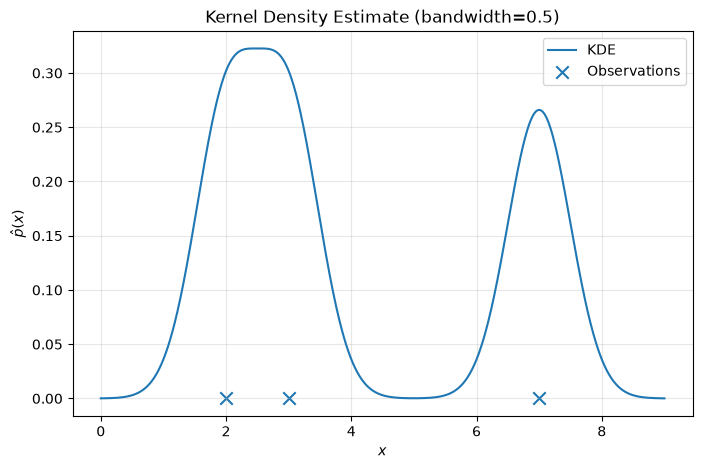

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(
    x,
    density,
    label="KDE",
)

plt.scatter(
    observations,
    np.zeros_like(observations),
    marker="x",
    s=80,
    label="Observations",
)

plt.xlabel(r"$x$")
plt.ylabel(r"$\hat{p}(x)$")
plt.title(
    f"Kernel Density Estimate "
    f"(bandwidth={bandwidth})"
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

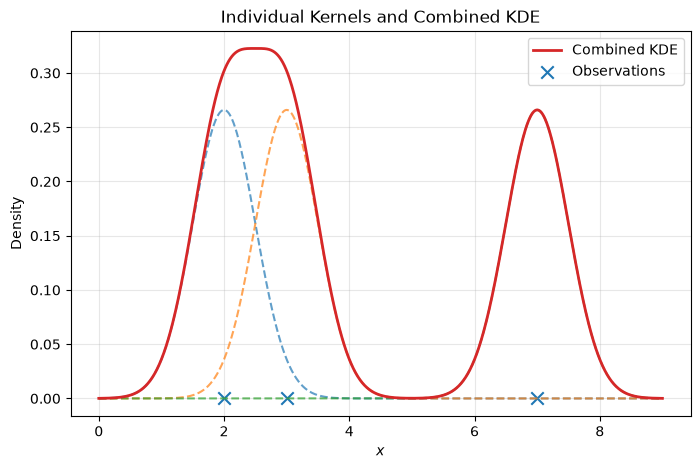

In [5]:
plt.figure(figsize=(8, 5))

for observation in observations:

    kernel = gaussian_kernel(
        x - observation,
        bandwidth,
    )

    plt.plot(
        x,
        kernel / len(observations),
        linestyle="--",
        alpha=0.7,
    )

plt.plot(
    x,
    density,
    linewidth=2,
    label="Combined KDE",
)

plt.scatter(
    observations,
    np.zeros_like(observations),
    marker="x",
    s=80,
    label="Observations",
)

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title("Individual Kernels and Combined KDE")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

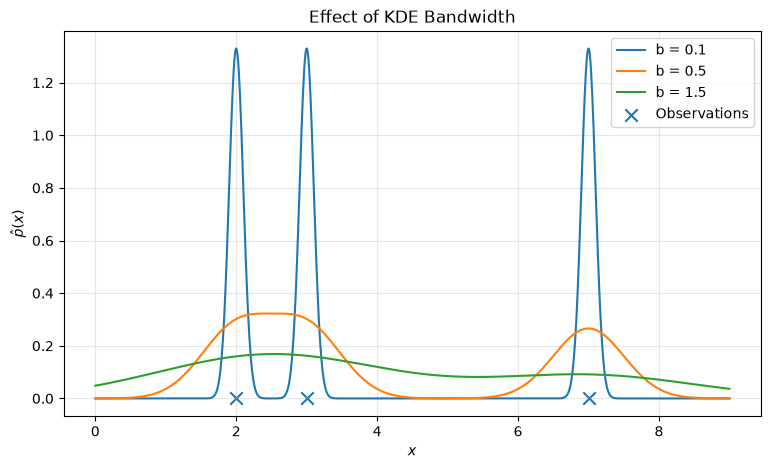

In [6]:
bandwidths = [
    0.1,
    0.5,
    1.5,
]

plt.figure(figsize=(9, 5))

for bandwidth in bandwidths:

    density = kernel_density_estimate(
        x,
        observations,
        bandwidth,
    )

    plt.plot(
        x,
        density,
        label=f"b = {bandwidth}",
    )

plt.scatter(
    observations,
    np.zeros_like(observations),
    marker="x",
    s=80,
    label="Observations",
)

plt.xlabel(r"$x$")
plt.ylabel(r"$\hat{p}(x)$")
plt.title("Effect of KDE Bandwidth")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Effect of Bandwidth

The bandwidth determines how strongly neighboring observations influence one another.

For a small bandwidth,

$$
b=0.1,
$$

each observation produces a narrow peak. The estimated density follows individual observations very closely.

For an intermediate bandwidth,

$$
b=0.5,
$$

nearby observations begin to combine into larger structures.

For a larger bandwidth,

$$
b=1.5,
$$

the kernels overlap substantially and the estimated density becomes much smoother.

Therefore,

$$
\boxed{
\text{Small }b
\rightarrow
\text{Low smoothing}
\rightarrow
\text{Potential overfitting}
}
$$

while

$$
\boxed{
\text{Large }b
\rightarrow
\text{High smoothing}
\rightarrow
\text{Potential underfitting}
}
$$

The bandwidth is therefore an important hyperparameter of kernel density estimation.

## Gaussian MLE vs Kernel Density Estimation

Suppose the observed data contains two distinct groups.

If we assume

$$
X\sim\mathcal{N}(\mu,\sigma^2),
$$

maximum likelihood estimation must describe all observations using a **single Gaussian distribution**.

The learned parameters are

$$
\hat{\mu}=
\frac{1}{N}\sum_{i=1}^{N}x_i
$$

and

$$
\hat{\sigma}^2=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{\mu})^2.
$$

However, if the true data distribution is multimodal, a single Gaussian may be an inappropriate model.

Kernel density estimation does not impose this single-Gaussian shape and can represent multiple modes directly from the observations.

In [7]:
rng = np.random.default_rng(42)

group_1 = rng.normal(
    loc=-2.0,
    scale=0.5,
    size=200,
)

group_2 = rng.normal(
    loc=3.0,
    scale=0.8,
    size=200,
)

bimodal_data = np.concatenate([
    group_1,
    group_2,
])

In [8]:
mu_mle = np.mean(
    bimodal_data
)

variance_mle = np.mean(
    (bimodal_data - mu_mle) ** 2
)

std_mle = np.sqrt(
    variance_mle
)

print(f"MLE mean: {mu_mle:.3f}")
print(f"MLE std:  {std_mle:.3f}")

MLE mean: 0.500
MLE std:  2.599


In [9]:
x = np.linspace(
    bimodal_data.min() - 2.0,
    bimodal_data.max() + 2.0,
    1000,
)

gaussian_density = gaussian_kernel(
    x - mu_mle,
    std_mle,
)

In [10]:
bandwidth = 0.4

kde_density = kernel_density_estimate(
    x,
    bimodal_data,
    bandwidth,
)

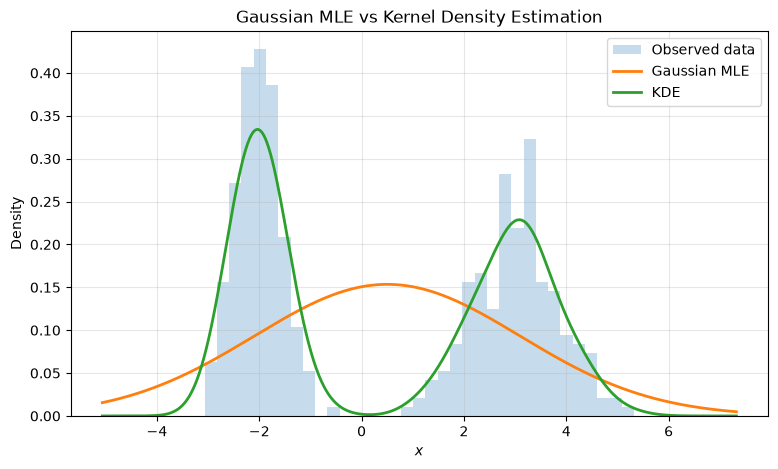

In [11]:
plt.figure(figsize=(9, 5))

plt.hist(
    bimodal_data,
    bins=35,
    density=True,
    alpha=0.25,
    label="Observed data",
)

plt.plot(
    x,
    gaussian_density,
    linewidth=2,
    label="Gaussian MLE",
)

plt.plot(
    x,
    kde_density,
    linewidth=2,
    label="KDE",
)

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title("Gaussian MLE vs Kernel Density Estimation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The Gaussian MLE correctly finds the mean and variance that maximize the likelihood **within the assumed Gaussian model family**.

However, the model assumption itself is restrictive:

$$
p(x)=
\mathcal{N}(x;\mu,\sigma^2).
$$

A single Gaussian can only represent one Gaussian-shaped mode.

Therefore, when the observations contain multiple clusters, the learned Gaussian may place substantial probability density between the clusters.

Kernel density estimation instead constructs

$$
\hat{p}(x)=
\frac{1}{N}
\sum_{i=1}^{N}
\phi(x-x_i),
$$

allowing the density shape to adapt to the observed data.

In this example, KDE can preserve the two modes present in the observations.

Therefore,

$$
\boxed{
\text{Parametric Model}
\rightarrow
\text{Strong assumption about density shape}
}
$$

while

$$
\boxed{
\text{KDE}
\rightarrow
\text{More flexible data-driven density shape}
}
$$

## Robotics Example — Nonparametric Sensor-Noise Learning

Previously, we modeled sensor measurements as

$$
z_t=x_t+\epsilon_t,
$$

where $\epsilon_t$ represents measurement noise.

Using Gaussian maximum likelihood estimation, we assumed

$$
\epsilon_t
\sim
\mathcal{N}(\mu_\epsilon,\sigma_\epsilon^2)
$$

and learned the parameters

$$
\mu_\epsilon
\quad\text{and}\quad
\sigma_\epsilon^2.
$$

This approach assumes that the sensor errors follow a Gaussian distribution.

However, real sensor errors may contain:

- multiple modes,
- asymmetric errors,
- heavy tails,
- outliers,
- or other non-Gaussian structure.

Instead of assuming a Gaussian form, kernel density estimation can estimate the error distribution directly from observed error samples:

$$
\boxed{
\hat{p}(\epsilon)=
\frac{1}{N}
\sum_{i=1}^{N}
\phi(\epsilon-\epsilon_i)
}
$$

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

robot_data = pd.read_csv(
    "../Datasets/DecisionMakingDatasets/robotics/robot_sensor_log.csv"
)

robot_data.head()

,time_s,true_x_m,true_y_m,true_velocity_mps,true_heading_rad,gps_x_m,gps_y_m,lidar_x_m,lidar_y_m,velocity_measurement_mps,heading_measurement_rad,gps_error_x_m,gps_error_y_m,lidar_error_x_m,lidar_error_y_m
0,0.0,0.000000,0.000000,1.280000,0.040000,0.389171,-0.116192,-0.186955,0.000243,1.368620,0.057620,0.389171,-0.116192,-0.186955,0.000243
1,0.1,0.127898,0.005119,1.284499,0.041800,-0.127170,0.305739,0.147994,0.067447,1.211959,0.055796,-0.255068,0.300621,0.020097,0.062329
2,0.2,0.256235,0.010486,1.288994,0.043599,0.283851,0.160250,0.495614,0.418710,1.165425,0.037359,0.027616,0.149763,0.239378,0.408224
3,0.3,0.385012,0.016104,1.293484,0.045397,-0.059789,0.137527,0.093869,-0.082504,1.349801,0.062646,-0.444801,0.121423,-0.291144,-0.098608
4,0.4,0.514227,0.021974,1.297968,0.047194,0.915233,0.474460,0.072914,0.398295,1.263833,0.063715,0.401005,0.452486,-0.441314,0.376320


In [16]:
gps_x_error = (
    robot_data["gps_x_m"].to_numpy()
    - robot_data["true_x_m"].to_numpy()
)

In [17]:
error_mean = np.mean(
    gps_x_error
)

error_variance = np.mean(
    (gps_x_error - error_mean) ** 2
)

error_std = np.sqrt(
    error_variance
)

print(
    f"Estimated bias: {error_mean:.3f}"
)

print(
    f"Estimated standard deviation: "
    f"{error_std:.3f}"
)

Estimated bias: 0.017
Estimated standard deviation: 0.608


In [18]:
x_error = np.linspace(
    gps_x_error.min() - 1.0,
    gps_x_error.max() + 1.0,
    1000,
)

bandwidth = 0.2

error_kde = kernel_density_estimate(
    x_error,
    gps_x_error,
    bandwidth,
)

In [19]:
error_gaussian = gaussian_kernel(
    x_error - error_mean,
    error_std,
)

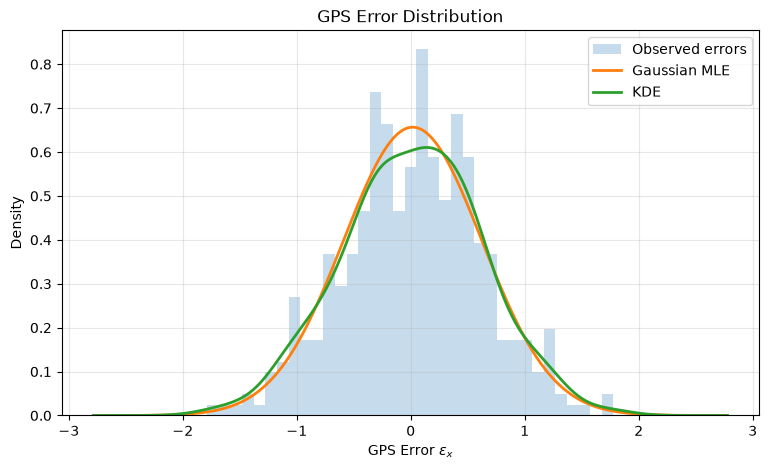

In [20]:
plt.figure(figsize=(9, 5))

plt.hist(
    gps_x_error,
    bins=35,
    density=True,
    alpha=0.25,
    label="Observed errors",
)

plt.plot(
    x_error,
    error_gaussian,
    linewidth=2,
    label="Gaussian MLE",
)

plt.plot(
    x_error,
    error_kde,
    linewidth=2,
    label="KDE",
)

plt.xlabel(r"GPS Error $\epsilon_x$")
plt.ylabel("Density")
plt.title("GPS Error Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Discussion

There are two ways to model the sensor-error distribution.

#### Parametric Approach

Assume

$$
\epsilon
\sim
\mathcal N(\mu_\epsilon,\sigma_\epsilon^2)
$$

and estimate

$$
\mu_\epsilon
\quad\text{and}\quad
\sigma_\epsilon^2
$$

from the observed errors.

This produces a compact model but assumes that the error distribution is Gaussian.

#### Nonparametric Approach

Kernel density estimation instead computes

$$
\hat p(\epsilon)=
\frac{1}{N}
\sum_{i=1}^{N}
\phi(\epsilon-\epsilon_i).
$$

The shape of the density is determined more directly by the observed errors.

This provides greater flexibility when the actual sensor-error distribution is not well represented by a simple parametric model.

The trade-off is therefore

$$
\boxed{
\text{Parametric}
\rightarrow
\text{Compact model + stronger assumptions}
}
$$

versus

$$
\boxed{
\text{Nonparametric}
\rightarrow
\text{Flexible model + greater data/computation dependence}
}
$$

## Nonparametric Learning — Summary

```text
                 Observed Data
                      │
          ┌───────────┴───────────┐
          ↓                       ↓
     Parametric              Nonparametric
       Learning                 Learning
          │                       │
          ↓                       ↓
 Assume Model Form          Avoid Fixed
 e.g. Gaussian              Density Form
          │                       │
          ↓                       ↓
 Learn Parameters           Place Kernel at
     μ, σ²                  Each Observation
                                  │
                                  ↓
                           Average Kernels
                                  │
                                  ↓
                               KDE p̂(x)
                                  │
                                  ↓
                         Bandwidth Controls
                            Smoothness